# options-pricer: end-to-end walkthrough

This notebook runs the whole project end to end as a narrative: Black-Scholes pricing →
Greeks → implied volatility → live market data → discrete delta-hedging simulation. It's
meant to be readable without opening `src/` — every cell calls into the actual package
(`options_pricer`), so what you see here is exactly what the test suite and the plotting
scripts in `scripts/` exercise, just narrated.

See [README.md](../README.md) for the project summary, results, and honest limitations,
and [CLAUDE.md](../CLAUDE.md) for the engineering rules this repo follows (pure functions,
one test per pricing/risk function, no third-party pricing libraries in `src/`).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Black-Scholes-Merton pricing

The model prices a European option by treating the future log-price as normally
distributed and computing a discounted, probability-weighted expected payoff:

```
C = S * exp(-qT) * N(d1)  -  K * exp(-rT) * N(d2)
```

`N(d2)` is (under the risk-neutral measure) the probability the option finishes in the
money; `N(d1)` is the same idea but under the "stock-as-numeraire" measure, which is why
it's shifted from `d2` by exactly `sigma * sqrt(T)`.

We validate this isn't just "a formula that runs" — it's checked in
[tests/test_black_scholes.py](../tests/test_black_scholes.py) against put-call parity, a
deep ITM/OTM limit, three independently-verified published reference prices (cited by
source), and an independent cross-check library (`py_vollib`, tests-only per CLAUDE.md).

In [2]:
from options_pricer.black_scholes import bsm_price

# Hull, "Options, Futures, and Other Derivatives" (2009), p.294:
# S0=42, K=40, r=10%, sigma=20%, T=0.5y, no dividend -> published c=4.76, p=0.81
call = bsm_price(S=42, K=40, T=0.5, r=0.10, sigma=0.20, option_type="call")
put = bsm_price(S=42, K=40, T=0.5, r=0.10, sigma=0.20, option_type="put")
print(f"call = {call:.4f}  (Hull: 4.76)")
print(f"put  = {put:.4f}  (Hull: 0.81)")

# Put-call parity: C - P = S*exp(-qT) - K*exp(-rT)
parity_lhs = call - put
parity_rhs = 42 * np.exp(0) - 40 * np.exp(-0.10 * 0.5)
print(f"\nput-call parity check: {parity_lhs:.6f} vs {parity_rhs:.6f}")

call = 4.7594  (Hull: 4.76)
put  = 0.8086  (Hull: 0.81)

put-call parity check: 3.950823 vs 3.950823


## 2. Greeks

Every Greek is a closed-form derivative of the pricing formula, reusing the same `d1`/`d2`
helpers. Gamma and vega are *provably* identical for a call and a put at the same strike
— directly from put-call parity, since `C - P = S*exp(-qT) - K*exp(-rT)` is linear in `S`
and doesn't depend on `sigma` at all, so its second `S`-derivative and its `sigma`-derivative
are both zero.

**Units matter and are easy to get wrong** — vega here is the raw `dV/dsigma` (price
change per 1.00, i.e. 100 percentage points, of vol), and theta is per *year*, not per
day. Both are documented explicitly in the docstrings so nobody has to guess.

In [3]:
from options_pricer.greeks import delta, gamma, vega, theta, rho, numerical_greek

S, K, T, r, sigma, q = 100.0, 100.0, 0.5, 0.05, 0.20, 0.0

print("ATM call Greeks:")
print(f"  delta = {delta(S, K, T, r, sigma, q, 'call'):.4f}")
print(f"  gamma = {gamma(S, K, T, r, sigma, q):.4f}")
print(f"  vega  = {vega(S, K, T, r, sigma, q):.4f}   (per 1.00 = 100pt move in sigma; divide by 100 for 'per 1 vol point')")
print(f"  theta = {theta(S, K, T, r, sigma, q, 'call'):.4f}   (per year; divide by 365 for 'per calendar day')")
print(f"  rho   = {rho(S, K, T, r, sigma, q, 'call'):.4f}   (per 1.00 = 100pt move in r)")

# Every closed-form Greek is cross-checked against central finite differences -
# the same tool the test suite uses (tests/test_greeks.py).
numeric_delta = numerical_greek(
    bsm_price, "S", bump=1e-3, S=S, K=K, T=T, r=r, sigma=sigma, q=q, option_type="call"
)
print(f"\nclosed-form delta = {delta(S, K, T, r, sigma, q, 'call'):.6f}")
print(f"finite-diff delta = {numeric_delta:.6f}")

ATM call Greeks:
  delta = 0.5977
  gamma = 0.0274
  vega  = 27.3587   (per 1.00 = 100pt move in sigma; divide by 100 for 'per 1 vol point')
  theta = -8.1160   (per year; divide by 365 for 'per calendar day')
  rho   = 26.4424   (per 1.00 = 100pt move in r)

closed-form delta = 0.597734
finite-diff delta = 0.597734


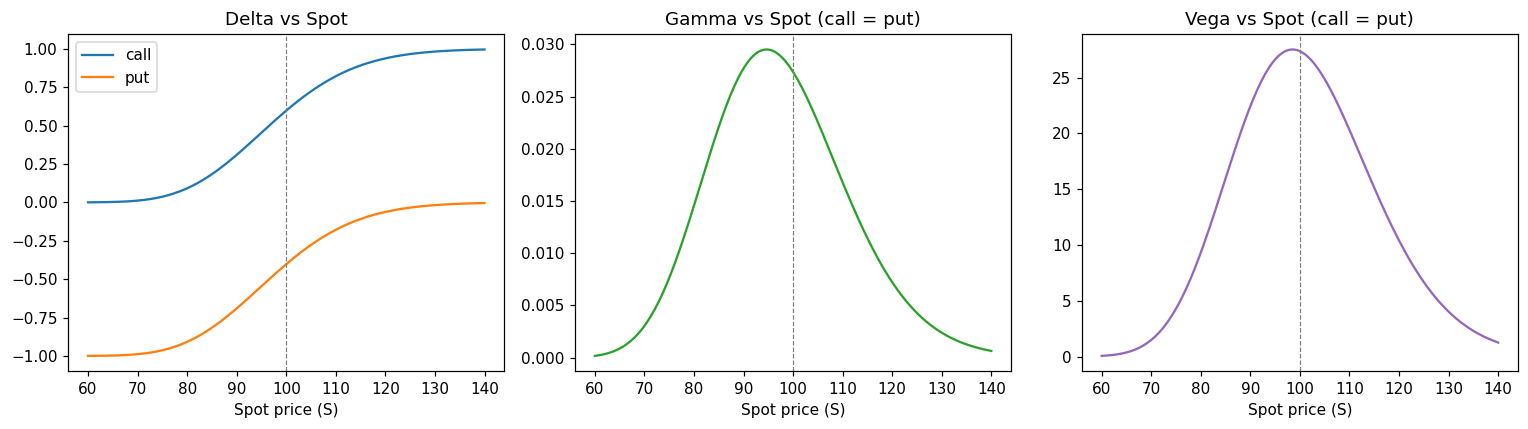


Full 5-panel version (+ theta, rho, + multi-expiry variants) is in plots/greeks_vs_spot.png,
generated by scripts/generate_greek_plots.py.


In [4]:
S_range = np.linspace(60, 140, 200)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(S_range, delta(S_range, K, T, r, sigma, q, "call"), label="call")
axes[0].plot(S_range, delta(S_range, K, T, r, sigma, q, "put"), label="put")
axes[0].set_title("Delta vs Spot")
axes[0].legend()

axes[1].plot(S_range, gamma(S_range, K, T, r, sigma, q), color="tab:green")
axes[1].set_title("Gamma vs Spot (call = put)")

axes[2].plot(S_range, vega(S_range, K, T, r, sigma, q), color="tab:purple")
axes[2].set_title("Vega vs Spot (call = put)")

for ax in axes:
    ax.axvline(K, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Spot price (S)")

fig.tight_layout()
plt.show()
print("\nFull 5-panel version (+ theta, rho, + multi-expiry variants) is in plots/greeks_vs_spot.png,")
print("generated by scripts/generate_greek_plots.py.")

## 3. Implied volatility

Inverting price -> volatility is the market's actual quoting convention. We solve it with
Newton-Raphson (using the closed-form vega for the step, and a Brenner-Subrahmanyam
approximation as the starting guess), falling back to Brent's method whenever Newton is
fragile — deep ITM/OTM or very short-dated, where vega collapses and a tiny price
tolerance implies a huge volatility tolerance.

In [5]:
from options_pricer.implied_vol import implied_vol

true_sigma = 0.27
price = bsm_price(S=100, K=105, T=0.4, r=0.04, sigma=true_sigma, q=0.01, option_type="call")
recovered = implied_vol(price, S=100, K=105, T=0.4, r=0.04, q=0.01, option_type="call")
print(f"true sigma      = {true_sigma}")
print(f"recovered sigma = {recovered:.8f}")
print(f"round-trip error = {abs(recovered - true_sigma):.2e}")

# A price that violates the no-arbitrage lower bound returns NaN, not an exception -
# and logs why (see the logging config in implied_vol.py).
import logging
logging.basicConfig(level=logging.WARNING, force=True)
bad = implied_vol(market_price=1.0, S=100, K=80, T=1.0, r=0.05, q=0.0, option_type="call")
print(f"\nimplied vol for an arbitrage-violating price: {bad}")

true sigma      = 0.27
recovered sigma = 0.27000000
round-trip error = 5.55e-16

implied vol for an arbitrage-violating price: nan


## 4. Live market data: SPY option chain -> volatility smile

This cell hits the network (Yahoo Finance via `yfinance`). It fetches a handful of real
SPY expiries, cleans the chain (drops zero-bid/stale contracts, computes bid-ask mid and
time-to-expiry, filters to reasonable moneyness), pulls the current risk-free rate and
dividend yield, and inverts every contract's price into an implied vol. Numbers below are
a live snapshot as of whenever this cell last ran — see
[README limitations](../README.md#limitations) for the data-quality caveats (a real
fraction of contracts fail to invert due to stale-quote arbitrage violations, and that's
expected, not a bug).

In [6]:
from options_pricer.data import fetch_option_chain, clean_option_chain, get_spot_price, get_risk_free_rate, get_dividend_yield

TICKER = "SPY"
spot = get_spot_price(TICKER)
r_live = get_risk_free_rate()
q_live = get_dividend_yield(TICKER)
print(f"{TICKER} spot={spot:.2f}  r={r_live:.4f}  q={q_live:.4f}")

raw_chain = fetch_option_chain(TICKER, max_expiries=3)
clean = clean_option_chain(raw_chain, spot=spot)
print(f"raw contracts: {len(raw_chain)}  ->  cleaned: {len(clean)}")

# The next loop deliberately hits some arbitrage-bound violations (see
# README limitations) - each one logs a WARNING. We already demonstrated
# that logging behavior explicitly above on a single quote; here we raise
# this logger's level so dozens of expected per-contract warnings don't
# bury the narrative output below.
logging.getLogger("options_pricer.implied_vol").setLevel(logging.ERROR)

clean = clean.copy()
clean["implied_vol"] = [
    implied_vol(row.mid, spot, row.strike, row.T, r_live, q_live, row.option_type)
    for row in clean.itertuples(index=False)
]
solved = clean.dropna(subset=["implied_vol"])
print(f"implied vol solved for {len(solved)}/{len(clean)} cleaned contracts")
print(f"({len(clean) - len(solved)} failed the no-arbitrage bound check - see README limitations)")

SPY spot=773.26  r=0.0371  q=0.0101


raw contracts: 519  ->  cleaned: 358


implied vol solved for 303/358 cleaned contracts
(55 failed the no-arbitrage bound check - see README limitations)


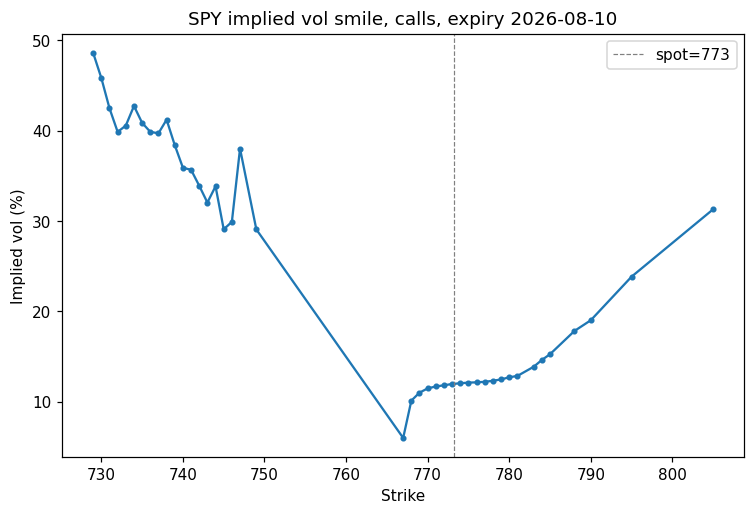


Full smile/term-structure/surface plots (more expiries) are in plots/,
generated by scripts/generate_vol_surface_plots.py.


In [7]:
nearest_expiry = sorted(solved["expiry"].unique())[0]
smile = solved[(solved["expiry"] == nearest_expiry) & (solved["option_type"] == "call")].sort_values("strike")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(smile["strike"], smile["implied_vol"] * 100, marker="o", markersize=3)
ax.axvline(spot, color="grey", linestyle="--", linewidth=0.8, label=f"spot={spot:.0f}")
ax.set_title(f"{TICKER} implied vol smile, calls, expiry {nearest_expiry}")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied vol (%)")
ax.legend()
plt.show()
print("\nFull smile/term-structure/surface plots (more expiries) are in plots/,")
print("generated by scripts/generate_vol_surface_plots.py.")

## 5. Discrete delta-hedging simulation

The scenario: sell one European call, delta-hedge it by trading the underlying at fixed
intervals until expiry, financing the cash account at the risk-free rate. The path is
simulated at its own "realised" volatility, separate from the "hedge" volatility used to
price the option and compute delta at each rebalance — the gap between the two is what
actually drives hedging P&L.

sigma_realised == sigma_hedge: mean P&L = +0.0071, std = 0.4288


(mean should sit close to zero - a matched-vol delta hedge is a replication argument, not a directional bet)


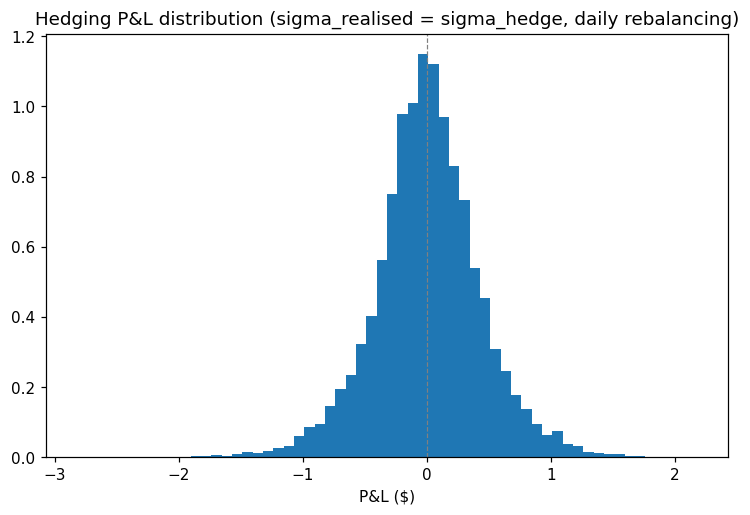

In [8]:
from options_pricer.hedging import run_hedge_simulation

S0, K_h, T_h, r_h, q_h = 100.0, 100.0, 0.25, 0.05, 0.0
sigma_hedge = 0.20

pnl_matched = run_hedge_simulation(S0, K_h, T_h, r_h, sigma_hedge, sigma_hedge, n_steps=63, n_paths=10_000, q=q_h, seed=1)
print(f"sigma_realised == sigma_hedge: mean P&L = {pnl_matched.mean():+.4f}, std = {pnl_matched.std():.4f}")
print("(mean should sit close to zero - a matched-vol delta hedge is a replication argument, not a directional bet)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pnl_matched, bins=60, density=True)
ax.axvline(0.0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Hedging P&L distribution (sigma_realised = sigma_hedge, daily rebalancing)")
ax.set_xlabel("P&L ($)")
plt.show()

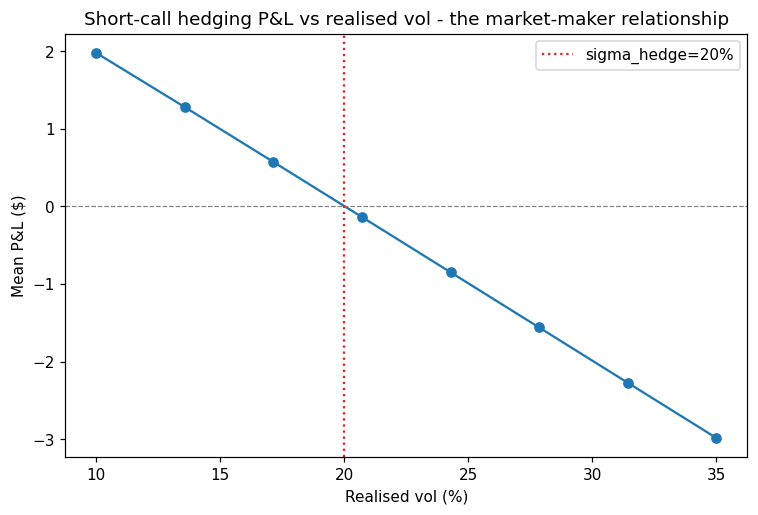

Below sigma_hedge: the seller profits (collected more theta than the stock's actual
wiggling cost via gamma). Above it: the seller loses. This is a short-gamma position -
see README 'What I learned' and the delta-hedging Q&A for the full mechanism.


In [9]:
realised_vols = np.linspace(0.10, 0.35, 8)
means = [
    run_hedge_simulation(S0, K_h, T_h, r_h, sigma_hedge, sr, n_steps=63, n_paths=8_000, q=q_h, seed=2).mean()
    for sr in realised_vols
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(realised_vols * 100, means, marker="o")
ax.axhline(0.0, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(sigma_hedge * 100, color="tab:red", linestyle=":", label=f"sigma_hedge={sigma_hedge*100:.0f}%")
ax.set_title("Short-call hedging P&L vs realised vol - the market-maker relationship")
ax.set_xlabel("Realised vol (%)")
ax.set_ylabel("Mean P&L ($)")
ax.legend()
plt.show()

print("Below sigma_hedge: the seller profits (collected more theta than the stock's actual")
print("wiggling cost via gamma). Above it: the seller loses. This is a short-gamma position -")
print("see README 'What I learned' and the delta-hedging Q&A for the full mechanism.")

## Where to go next

- [README.md](../README.md) — results, what I learned, and an honest limitations section
  (European-only, GBM/constant-vol assumption, day-count convention inconsistency, live
  data quality caveats).
- `scripts/` — the full-scale versions of every experiment above (more paths, more
  expiries, more rebalancing frequencies, transaction-cost tradeoffs), which write the
  final plots to `plots/`.
- `tests/` — 81 tests, including the finite-difference Greek cross-checks, the
  round-trip implied vol property test, and a direct numerical check that simulated
  hedging P&L matches the theoretical gamma-P&L integral.